
# Oil Price Forecasting with Exogenous Economic Indicators

This notebook is organized as a complete, step-by-step workflow for forecasting weekly oil prices using both classical time-series models and artificial neural networks.

## Objectives
1. Build a strong **ARIMA baseline** using only oil price.
2. Build a **SARIMAX model** using oil price with **US Index** as an exogenous variable.
3. Build an **ANN model using oil-only features**.
4. Build an **ANN model using oil + US Index features**.
5. Compare all models using the same evaluation metrics.

## Main sections
1. Setup and data loading
2. Data understanding and cleaning
3. Exploratory data analysis (EDA)
4. Weekly aggregation and outlier treatment
5. Modeling datasets
6. ARIMA automated hyperparameter tuning
7. SARIMAX automated hyperparameter tuning
8. ANN with oil-only inputs
9. ANN with oil + US Index inputs
10. Final comparison and conclusion



## 1. Setup and imports

This section loads all required libraries for:
- data manipulation
- visualization
- preprocessing
- time-series forecasting
- neural network modeling
- evaluation


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from math import sqrt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)



## 2. Load the dataset

Update the file path if needed. The dataset is expected to contain at least:
- `Date`
- `Oilprice`
- `us-index`


In [2]:

file_path = r'Data/final_oil-us-indexv1.csv'

data = pd.read_csv(file_path)
print('Raw shape:', data.shape)
data.head()


Raw shape: (4918, 3)


,Date,Oilprice,us-index
0,1/3/2005,42.16,81.30
1,1/4/2005,43.96,82.57
2,1/5/2005,43.41,82.54
3,1/6/2005,45.51,83.15
4,1/7/2005,45.32,83.61


In [3]:
data.tail()

,Date,Oilprice,us-index
4913,4/5/2024,87.69,104.30
4914,4/8/2024,87.24,104.14
4915,4/9/2024,86.04,104.15
4916,4/10/2024,86.98,105.25
4917,4/11/2024,85.79,105.28



## 3. Initial preprocessing

This section:
1. converts the `Date` column into datetime format
2. sorts the data chronologically
3. sets `Date` as the index
4. checks data types and missing values


In [4]:

# Convert Date and set index
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').set_index('Date')

print(type(data.index))
print('Data types:')
print(data.dtypes)
print('Missing values:')
print(data.isna().sum())

data.head()


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Data types:
Oilprice    float64
us-index    float64
dtype: object
Missing values:
Oilprice    76
us-index    10
dtype: int64


,Oilprice,us-index
Date,,
2005-01-03,42.16,81.30
2005-01-04,43.96,82.57
2005-01-05,43.41,82.54
2005-01-06,45.51,83.15
2005-01-07,45.32,83.61



## 4. Exploratory Data Analysis (EDA)

This section is important because it helps answer these questions:
- What does the raw time series look like?
- Are there missing values?
- How are the variables distributed?
- Is there a visible relationship between oil price and US Index?
- Is there a lagged relationship between the two variables?


### 4.1 Time-series visualization

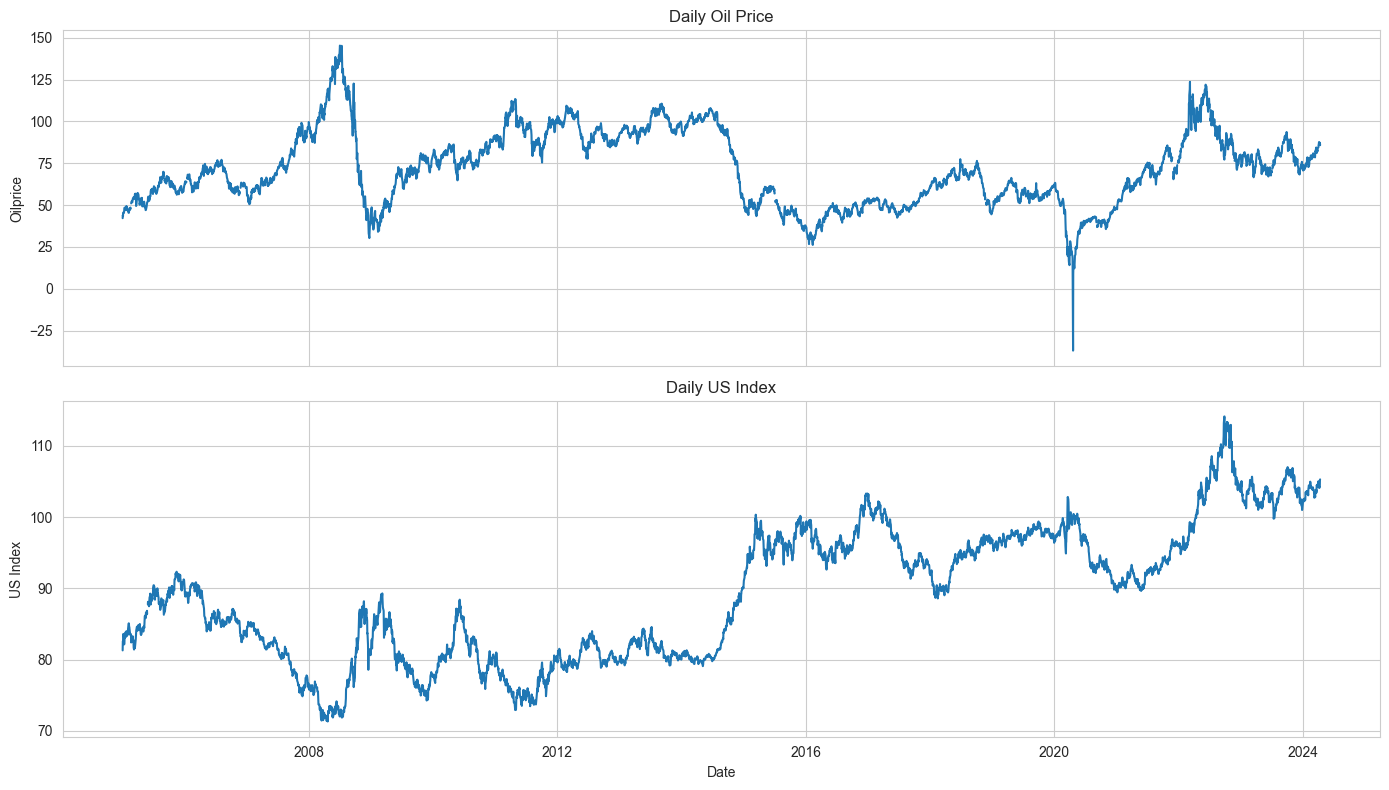

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, data['Oilprice'])
axes[0].set_title('Daily Oil Price')
axes[0].set_ylabel('Oilprice')

axes[1].plot(data.index, data['us-index'])
axes[1].set_title('Daily US Index')
axes[1].set_ylabel('US Index')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


### 4.2 Distribution plots

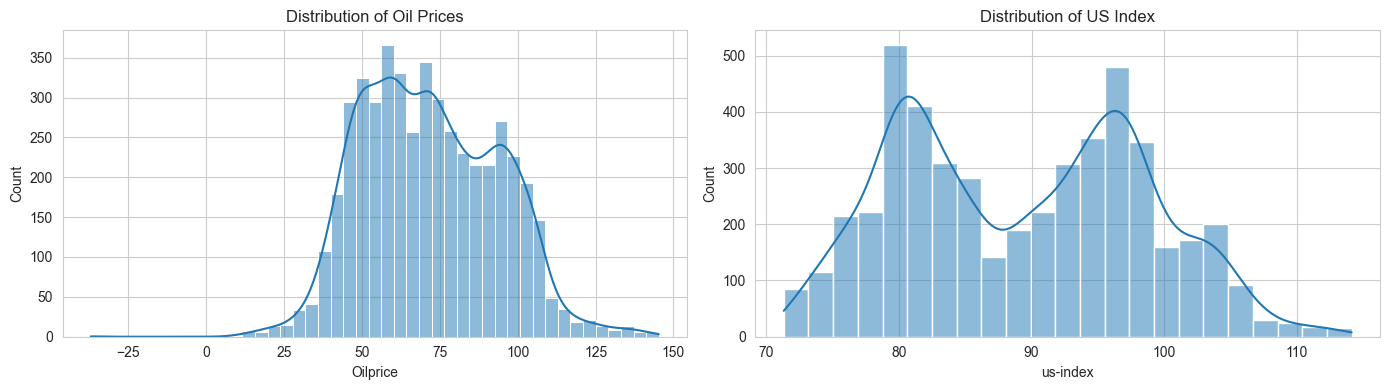

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data['Oilprice'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Oil Prices')

sns.histplot(data['us-index'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribution of US Index')

plt.tight_layout()
plt.show()


### 4.3 Missing-value analysis

Missing values by column:
Oilprice    76
us-index    10
dtype: int64


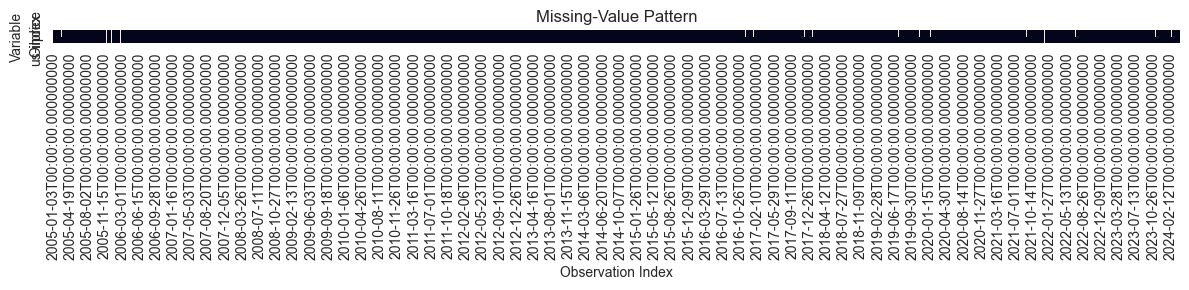

In [7]:

print('Missing values by column:')
print(data.isna().sum())

plt.figure(figsize=(12, 3))
sns.heatmap(data.isna().T, cbar=False)
plt.title('Missing-Value Pattern')
plt.xlabel('Observation Index')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


### 4.4 Correlation analysis in EDA

Daily correlation matrix:
          Oilprice  us-index
Oilprice  1.000000 -0.473874
us-index -0.473874  1.000000


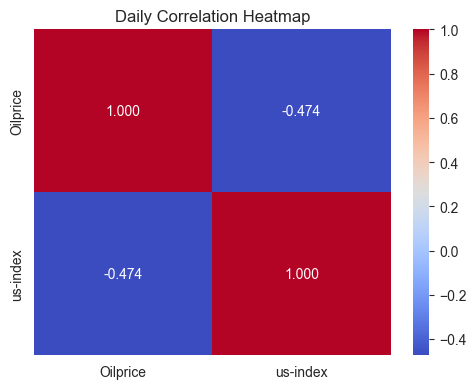

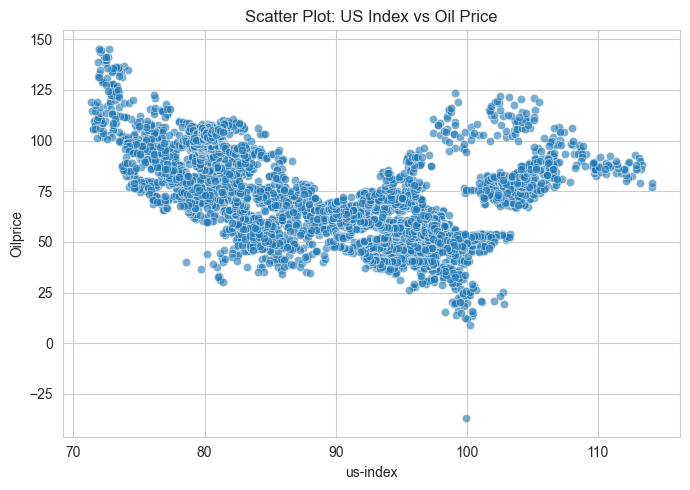

In [8]:

# Pearson correlation on daily data
corr_daily = data[['Oilprice', 'us-index']].corr()
print('Daily correlation matrix:')
print(corr_daily)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_daily, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Daily Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=data.reset_index(), x='us-index', y='Oilprice', alpha=0.6)
plt.title('Scatter Plot: US Index vs Oil Price')
plt.tight_layout()
plt.show()


### 4.5 Lagged correlation analysis

   Lag_Weeks_or_Days  Correlation
0                  0    -0.473874
1                  1    -0.474945
2                  2    -0.475819
3                  3    -0.476813
4                  4    -0.477594
5                  5    -0.478378
6                  6    -0.479227
7                  7    -0.480187
8                  8    -0.481088


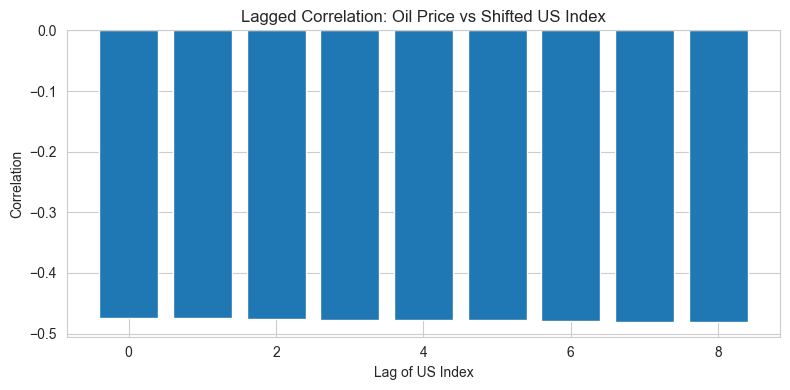

In [9]:

max_lag = 8
lag_corr = []

for lag in range(0, max_lag + 1):
    corr_val = data['Oilprice'].corr(data['us-index'].shift(lag))
    lag_corr.append({'Lag_Weeks_or_Days': lag, 'Correlation': corr_val})

lag_corr_df = pd.DataFrame(lag_corr)
print(lag_corr_df)

plt.figure(figsize=(8, 4))
plt.bar(lag_corr_df['Lag_Weeks_or_Days'], lag_corr_df['Correlation'])
plt.title('Lagged Correlation: Oil Price vs Shifted US Index')
plt.xlabel('Lag of US Index')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()



## 5. Missing-value treatment

After removing continuous missing blocks outside this notebook, the remaining missing values are treated using:
1. **linear interpolation** for local continuity
2. **forward fill / backward fill** for any remaining edge cases


In [10]:
data_imputed = data.copy()
data_imputed['Oilprice'] = data_imputed['Oilprice'].interpolate(method='linear')
data_imputed['us-index'] = data_imputed['us-index'].interpolate(method='linear')
data_imputed = data_imputed.ffill().bfill()

print('Missing values after imputation:')
print(data_imputed.isna().sum())


Missing values after imputation:
Oilprice    0
us-index    0
dtype: int64



## 6. Weekly aggregation

The study uses weekly frequency to:
- reduce noise from daily volatility
- align the dataset for forecasting
- make seasonal modeling more manageable

`W-FRI` is used so that each observation represents a week ending on Friday.


In [11]:
weekly_data = data_imputed.resample('W-FRI').mean()
print('Weekly shape:', weekly_data.shape)
weekly_data.head()


Weekly shape: (1006, 2)


,Oilprice,us-index
Date,,
2005-01-07,44.072,82.634
2005-01-14,46.790,82.804
2005-01-21,47.965,83.424
2005-01-28,48.558,83.488
2005-02-04,46.970,83.786



## 7. Outlier detection and treatment on weekly oil price

Because the target variable is oil price, outlier handling is applied to `Oilprice` only.
The IQR method is used to detect extreme values, and **capping** is used instead of row deletion.


In [12]:

col = 'Oilprice'

Q1 = weekly_data[col].quantile(0.25)
Q3 = weekly_data[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = weekly_data[(weekly_data[col] < lower_bound) | (weekly_data[col] > upper_bound)].copy()

print('IQR Statistics')
print('Q1         :', Q1)
print('Q3         :', Q3)
print('IQR        :', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)
print('Number of outliers:', len(outliers))
outliers.head()


IQR Statistics
Q1         : 53.99975
Q3         : 88.9195
IQR        : 34.91975
Lower Bound: 1.6201249999999945
Upper Bound: 141.299125
Number of outliers: 1


,Oilprice,us-index
Date,,
2008-07-04,142.5175,72.4


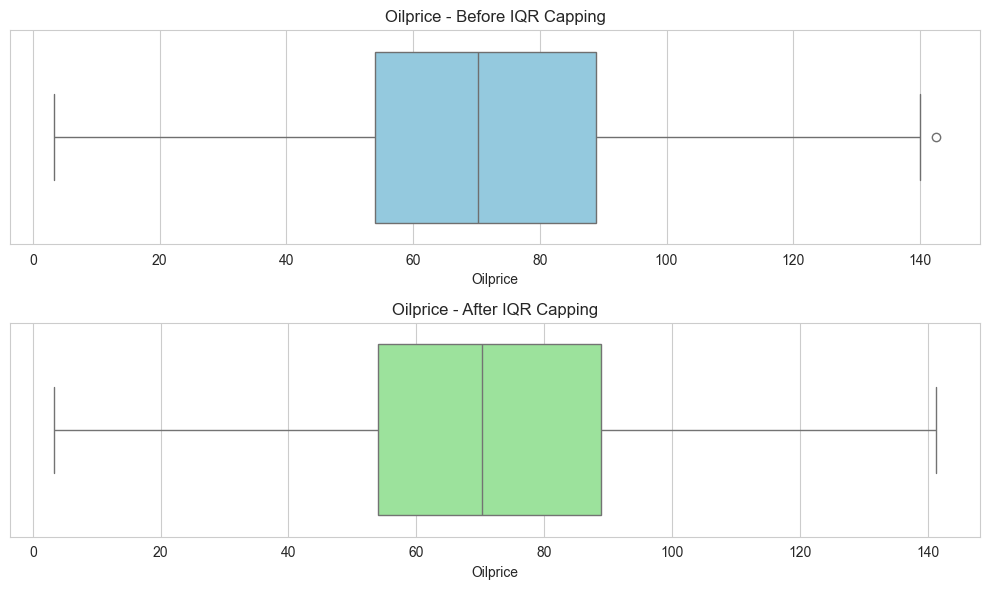

In [13]:

weekly_data_clean = weekly_data.copy()
weekly_data_clean['Oilprice'] = np.clip(weekly_data_clean['Oilprice'], lower_bound, upper_bound)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.boxplot(x=weekly_data['Oilprice'], ax=axes[0], color='skyblue')
axes[0].set_title('Oilprice - Before IQR Capping')

sns.boxplot(x=weekly_data_clean['Oilprice'], ax=axes[1], color='lightgreen')
axes[1].set_title('Oilprice - After IQR Capping')

plt.tight_layout()
plt.show()



## 8. Weekly EDA after preprocessing

This section re-checks the relationship using the final weekly dataset that will be used for modeling.


Weekly correlation matrix:
          Oilprice  us-index
Oilprice  1.000000 -0.474029
us-index -0.474029  1.000000


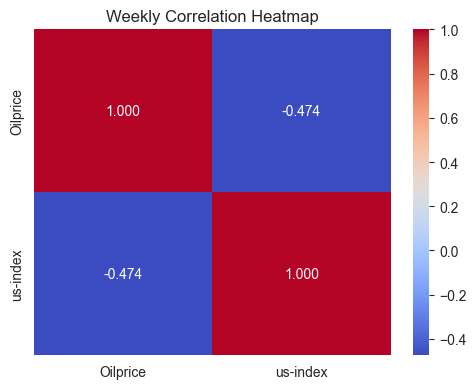

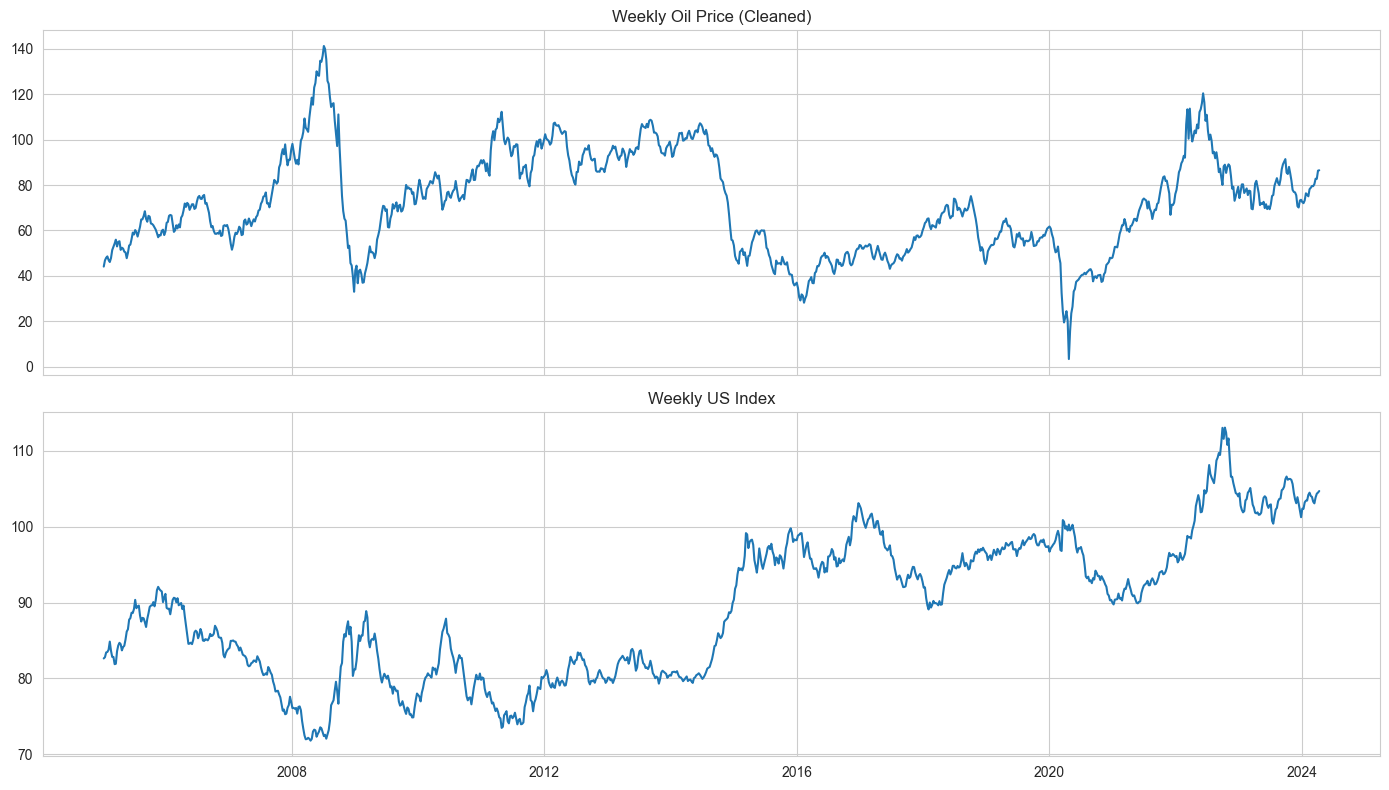

In [14]:

corr_weekly = weekly_data_clean[['Oilprice', 'us-index']].corr()
print('Weekly correlation matrix:')
print(corr_weekly)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_weekly, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Weekly Correlation Heatmap')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(weekly_data_clean.index, weekly_data_clean['Oilprice'])
axes[0].set_title('Weekly Oil Price (Cleaned)')
axes[1].plot(weekly_data_clean.index, weekly_data_clean['us-index'])
axes[1].set_title('Weekly US Index')
plt.tight_layout()
plt.show()



## 9. Utility functions

The next sections use shared utility functions for:
- metrics
- forecasting evaluation
- supervised lag feature creation


In [15]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    return {
        'RMSE': sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


def create_supervised_features(df, target_col='Oilprice', exog_cols=None, lags=4, include_current_exog=False):
    if exog_cols is None:
        exog_cols = []

    supervised = pd.DataFrame(index=df.index)
    supervised[target_col] = df[target_col]

    for lag in range(1, lags + 1):
        supervised[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)

    for exog_col in exog_cols:
        for lag in range(1, lags + 1):
            supervised[f'{exog_col}_lag_{lag}'] = df[exog_col].shift(lag)
        if include_current_exog:
            supervised[f'{exog_col}_current'] = df[exog_col]

    supervised = supervised.dropna()
    X = supervised.drop(columns=[target_col])
    y = supervised[target_col]
    return supervised, X, y


def train_test_split_time_series(X, y, train_ratio=0.8):
    split_idx = int(len(X) * train_ratio)
    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()
    return X_train, X_test, y_train, y_test



## 10. ARIMA baseline with automated hyperparameter tuning

### Purpose
This model serves as the **baseline** and uses only the historical oil price series.

### Hyperparameters
- `p`: autoregressive order
- `d`: differencing order
- `q`: moving average order

### Selection rule
The model with the **lowest RMSE on the test set** is selected.


In [16]:
series = weekly_data_clean['Oilprice'].dropna().copy()
train_size = int(len(series) * 0.8)
train_arima = series.iloc[:train_size]
test_arima = series.iloc[train_size:]

p_values = [0, 1, 2, 3]
d_values = [0, 1, 2]
q_values = [0, 1, 2, 3]

arima_results = []

for p, d, q in product(p_values, d_values, q_values):
    order = (p, d, q)
    try:
        model = ARIMA(train_arima, order=order)
        fitted = model.fit()
        forecast = fitted.forecast(steps=len(test_arima))

        metrics = regression_metrics(test_arima, forecast)
        arima_results.append({
            'order': order,
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            **metrics
        })
        print(f'ARIMA{order} -> RMSE={metrics["RMSE"]:.4f}, MAE={metrics["MAE"]:.4f}, MAPE={metrics["MAPE"]:.2f}%')
    except Exception as e:
        print(f'ARIMA{order} failed: {e}')

arima_results_df = pd.DataFrame(arima_results).sort_values('RMSE').reset_index(drop=True)
arima_results_df.head(10)


ARIMA(0, 0, 0) -> RMSE=19.1430, MAE=14.7869, MAPE=22.97%
ARIMA(0, 0, 1) -> RMSE=19.0641, MAE=14.7392, MAPE=22.82%
ARIMA(0, 0, 2) -> RMSE=18.9264, MAE=14.5937, MAPE=22.39%
ARIMA(0, 0, 3) -> RMSE=18.9191, MAE=14.6419, MAPE=22.52%
ARIMA(0, 1, 0) -> RMSE=44.1701, MAE=39.9198, MAPE=50.04%
ARIMA(0, 1, 1) -> RMSE=44.2212, MAE=39.9763, MAPE=50.13%
ARIMA(0, 1, 2) -> RMSE=44.0932, MAE=39.8346, MAPE=49.92%
ARIMA(0, 1, 3) -> RMSE=43.9066, MAE=39.6286, MAPE=49.62%
ARIMA(0, 2, 0) -> RMSE=89.3402, MAE=70.6681, MAPE=91.68%
ARIMA(0, 2, 1) -> RMSE=40.2493, MAE=36.1335, MAPE=45.19%
ARIMA(0, 2, 2) -> RMSE=45.4690, MAE=41.1649, MAPE=51.65%
ARIMA(0, 2, 3) -> RMSE=45.3387, MAE=41.0203, MAPE=51.44%
ARIMA(1, 0, 0) -> RMSE=30.1923, MAE=26.0627, MAPE=32.12%
ARIMA(1, 0, 1) -> RMSE=26.0468, MAE=21.7869, MAPE=26.55%
ARIMA(1, 0, 2) -> RMSE=25.2920, MAE=20.9986, MAPE=25.51%
ARIMA(1, 0, 3) -> RMSE=24.5264, MAE=20.2113, MAPE=24.50%
ARIMA(1, 1, 0) -> RMSE=43.8959, MAE=39.6165, MAPE=49.60%
ARIMA(1, 1, 1) -> RMSE=43.9812,

c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 0, 2) -> RMSE=24.0125, MAE=19.6604, MAPE=23.85%


c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 0, 3) -> RMSE=18.3722, MAE=14.0027, MAPE=17.04%
ARIMA(2, 1, 0) -> RMSE=43.9560, MAE=39.6830, MAPE=49.70%
ARIMA(2, 1, 1) -> RMSE=43.9742, MAE=39.7032, MAPE=49.73%
ARIMA(2, 1, 2) -> RMSE=41.1107, MAE=36.6016, MAPE=45.31%


...

ARIMA(3, 0, 3) -> RMSE=21.8900, MAE=17.3183, MAPE=20.82%
ARIMA(3, 1, 0) -> RMSE=43.5317, MAE=39.2156, MAPE=49.02%
ARIMA(3, 1, 1) -> RMSE=40.4852, MAE=35.9301, MAPE=44.36%
ARIMA(3, 1, 2) -> RMSE=38.0677, MAE=33.3314, MAPE=40.75%


c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(3, 1, 3) -> RMSE=28.7015, MAE=24.5536, MAPE=30.16%
ARIMA(3, 2, 0) -> RMSE=380.8706, MAE=324.8333, MAPE=417.25%
ARIMA(3, 2, 1) -> RMSE=44.5876, MAE=40.2176, MAPE=50.30%
ARIMA(3, 2, 2) -> RMSE=45.4515, MAE=41.1489, MAPE=51.63%
ARIMA(3, 2, 3) -> RMSE=44.2182, MAE=39.8079, MAPE=49.70%


c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,AIC,BIC,RMSE,MAE,MAPE,R2
0,"(2, 0, 3)",3958.131280,3990.958475,18.372167,14.002738,17.041775,0.055604
1,"(0, 0, 3)",5115.283317,5138.731313,18.919082,14.641890,22.522883,-0.001460
2,"(0, 0, 2)",5590.889465,5609.647862,18.926351,14.593664,22.392238,-0.002230
3,"(0, 0, 1)",6302.974962,6317.043760,19.064121,14.739234,22.822993,-0.016874
4,"(0, 0, 0)",7290.791940,7300.171138,19.142958,14.786876,22.972961,-0.025301
5,"(3, 0, 3)",3962.126513,3999.643307,21.889984,17.318252,20.819569,-0.340678
6,"(3, 0, 2)",3965.273635,3998.100830,22.769377,18.310846,22.141725,-0.450560
7,"(2, 0, 2)",3963.500542,3991.638137,24.012547,19.660428,23.851184,-0.613281
8,"(1, 0, 3)",3965.432358,3993.569953,24.526375,20.211334,24.498017,-0.683062
9,"(2, 0, 0)",3962.047972,3980.806370,24.604899,20.291560,24.600398,-0.693857


Best ARIMA order: (2, 0, 3)


c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': 18.37216658827708, 'MAE': 14.002738428735944, 'MAPE': np.float64(17.04177484663974), 'R2': 0.05560385428072634}


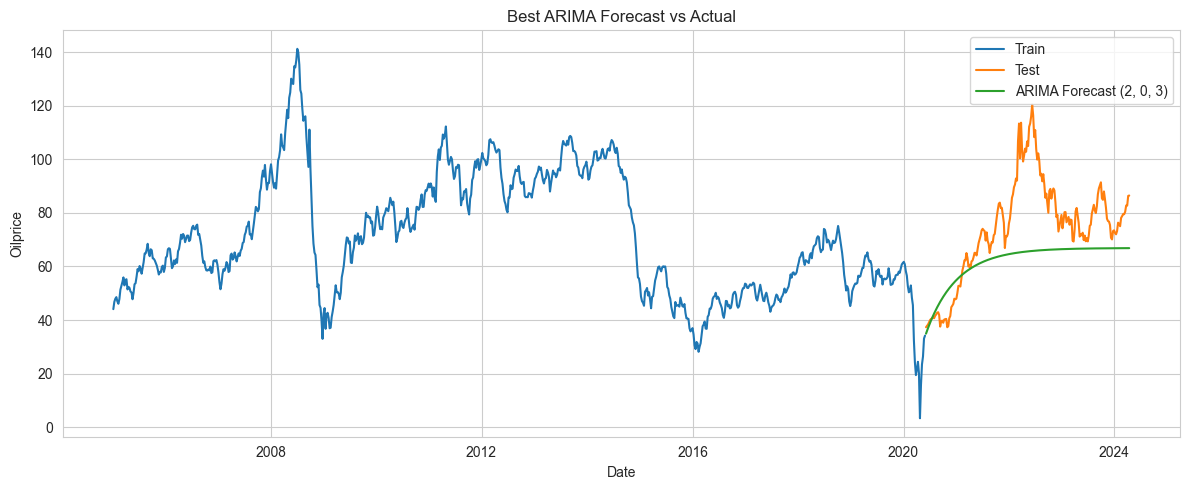

In [17]:

best_arima_order = arima_results_df.loc[0, 'order']
print('Best ARIMA order:', best_arima_order)

best_arima_model = ARIMA(train_arima, order=best_arima_order).fit()
best_arima_forecast = best_arima_model.forecast(steps=len(test_arima))

best_arima_metrics = regression_metrics(test_arima, best_arima_forecast)
print(best_arima_metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_arima.index, train_arima, label='Train')
plt.plot(test_arima.index, test_arima, label='Test')
plt.plot(test_arima.index, best_arima_forecast, label=f'ARIMA Forecast {best_arima_order}')
plt.title('Best ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Oilprice')
plt.legend()
plt.tight_layout()
plt.show()



## 11. SARIMAX with oil price + US Index and automated hyperparameter tuning

### Purpose
This model tests whether **US Index improves forecasting** when used as an exogenous variable.

### Hyperparameters
- non-seasonal: `(p, d, q)`
- seasonal: `(P, D, Q, s)`
- exogenous input: `us-index`

### Note
Because the data is weekly, a yearly seasonal cycle can be large (`s=52`). To keep the notebook manageable, the search below starts with **smaller seasonal periods**. You can expand later if runtime allows.


In [18]:

endog = weekly_data_clean['Oilprice'].dropna().copy()
exog = weekly_data_clean[['us-index']].copy().loc[endog.index]

train_size = int(len(endog) * 0.8)
train_endog = endog.iloc[:train_size]
test_endog = endog.iloc[train_size:]
train_exog = exog.iloc[:train_size]
test_exog = exog.iloc[train_size:]

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
seasonal_periods = [4, 12]  # you may add 52 if runtime allows

sarimax_results = []

for p, d, q in product(p_values, d_values, q_values):
    for P, D, Q, s in product(P_values, D_values, Q_values, seasonal_periods):
        order = (p, d, q)
        seasonal_order = (P, D, Q, s)
        try:
            model = SARIMAX(
                train_endog,
                exog=train_exog,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False)
            forecast = fitted.forecast(steps=len(test_endog), exog=test_exog)

            metrics = regression_metrics(test_endog, forecast)
            sarimax_results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                **metrics
            })
            print(f'SARIMAX{order}x{seasonal_order} -> RMSE={metrics["RMSE"]:.4f}, MAE={metrics["MAE"]:.4f}')
        except Exception as e:
            print(f'SARIMAX{order}x{seasonal_order} failed: {e}')

sarimax_results_df = pd.DataFrame(sarimax_results).sort_values('RMSE').reset_index(drop=True)
sarimax_results_df.head(10)


SARIMAX(0, 0, 0)x(0, 0, 0, 4) -> RMSE=17.1585, MAE=12.5336
SARIMAX(0, 0, 0)x(0, 0, 0, 12) -> RMSE=17.1585, MAE=12.5336
SARIMAX(0, 0, 0)x(0, 0, 1, 4) -> RMSE=16.3876, MAE=12.0044
SARIMAX(0, 0, 0)x(0, 0, 1, 12) -> RMSE=14.7280, MAE=10.4522
SARIMAX(0, 0, 0)x(0, 1, 0, 4) -> RMSE=51.4328, MAE=44.6586
SARIMAX(0, 0, 0)x(0, 1, 0, 12) -> RMSE=58.4921, MAE=50.5315
SARIMAX(0, 0, 0)x(0, 1, 1, 4) -> RMSE=50.4065, MAE=43.7631
SARIMAX(0, 0, 0)x(0, 1, 1, 12) -> RMSE=55.5760, MAE=47.2832
SARIMAX(0, 0, 0)x(1, 0, 0, 4) -> RMSE=53.0162, MAE=46.1265
SARIMAX(0, 0, 0)x(1, 0, 0, 12) -> RMSE=59.5898, MAE=51.5626
SARIMAX(0, 0, 0)x(1, 0, 1, 4) -> RMSE=52.5543, MAE=45.7396
SARIMAX(0, 0, 0)x(1, 0, 1, 12) -> RMSE=55.8494, MAE=47.6108
SARIMAX(0, 0, 0)x(1, 1, 0, 4) -> RMSE=49.9313, MAE=43.3437
SARIMAX(0, 0, 0)x(1, 1, 0, 12) -> RMSE=57.5919, MAE=49.4080
SARIMAX(0, 0, 0)x(1, 1, 1, 4) -> RMSE=49.8322, MAE=43.2867
SARIMAX(0, 0, 0)x(1, 1, 1, 12) -> RMSE=42.7418, MAE=35.4576
SARIMAX(0, 0, 1)x(0, 0, 0, 4) -> RMSE=17.0036, M

c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX(0, 0, 1)x(1, 0, 1, 4) -> RMSE=52.6774, MAE=45.8555
SARIMAX(0, 0, 1)x(1, 0, 1, 12) -> RMSE=51.0669, MAE=43.2371
SARIMAX(0, 0, 1)x(1, 1, 0, 4) -> RMSE=49.9634, MAE=43.4132
SARIMAX(0, 0, 1)x(1, 1, 0, 12) -> RMSE=57.8842, MAE=50.5058
SARIMAX(0, 0, 1)x(1, 1, 1, 4) -> RMSE=49.6923, MAE=43.1929
SARIMAX(0, 0, 1)x(1, 1, 1, 12) -> RMSE=41.5649, MAE=34.5052
SARIMAX(0, 0, 2)x(0, 0, 0, 4) -> RMSE=16.7434, MAE=12.1891
SARIMAX(0, 0, 2)x(0, 0, 0, 12) -> RMSE=16.7434, MAE=12.1891
SARIMAX(0, 0, 2)x(0, 0, 1, 4) -> RMSE=16.0581, MAE=11.6971
SARIMAX(0, 0, 2)x(0, 0, 1, 12) -> RMSE=14.5243, MAE=10.3639
SARIMAX(0, 0, 2)x(0, 1, 0, 4) -> RMSE=50.8485, MAE=44.4743
SARIMAX(0, 0, 2)x(0, 1, 0, 12) -> RMSE=58.4751, MAE=51.6579
SARIMAX(0, 0, 2)x(0, 1, 1, 4) -> RMSE=53.7151, MAE=47.0613
SARIMAX(0, 0, 2)x(0, 1, 1, 12) -> RMSE=43.1639, MAE=36.4527
SARIMAX(0, 0, 2)x(1, 0, 0, 4) -> RMSE=54.8767, MAE=48.2087
SARIMAX(0, 0, 2)x(1, 0, 0, 12) -> RMSE=62.4841, MAE=55.4268


c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX(0, 0, 2)x(1, 0, 1, 4) -> RMSE=55.7514, MAE=48.7942


...

SARIMAX(2, 0, 2)x(1, 0, 1, 4) -> RMSE=50.6103, MAE=44.1076


c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX(2, 0, 2)x(1, 0, 1, 12) -> RMSE=53.0477, MAE=46.2104
SARIMAX(2, 0, 2)x(1, 1, 0, 4) -> RMSE=45.3307, MAE=39.0656
SARIMAX(2, 0, 2)x(1, 1, 0, 12) -> RMSE=41.7628, MAE=35.8635
SARIMAX(2, 0, 2)x(1, 1, 1, 4) -> RMSE=33.8229, MAE=28.1429
SARIMAX(2, 0, 2)x(1, 1, 1, 12) -> RMSE=31.5317, MAE=25.9519
SARIMAX(2, 1, 0)x(0, 0, 0, 4) -> RMSE=47.5197, MAE=40.9910
SARIMAX(2, 1, 0)x(0, 0, 0, 12) -> RMSE=47.5197, MAE=40.9910
SARIMAX(2, 1, 0)x(0, 0, 1, 4) -> RMSE=47.3598, MAE=40.8279
SARIMAX(2, 1, 0)x(0, 0, 1, 12) -> RMSE=47.2948, MAE=40.7120
SARIMAX(2, 1, 0)x(0, 1, 0, 4) -> RMSE=372.8909, MAE=320.4037
SARIMAX(2, 1, 0)x(0, 1, 0, 12) -> RMSE=140.8590, MAE=127.3353
SARIMAX(2, 1, 0)x(0, 1, 1, 4) -> RMSE=53.1450, MAE=46.1173
SARIMAX(2, 1, 0)x(0, 1, 1, 12) -> RMSE=46.8022, MAE=40.3063
SARIMAX(2, 1, 0)x(1, 0, 0, 4) -> RMSE=47.3191, MAE=40.7882
SARIMAX(2, 1, 0)x(1, 0, 0, 12) -> RMSE=47.3299, MAE=40.7471
SARIMAX(2, 1, 0)x(1, 0, 1, 4) -> RMSE=46.8997, MAE=40.3876
SARIMAX(2, 1, 0)x(1, 0, 1, 12) -> RMSE=47.22

c:\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC,RMSE,MAE,MAPE,R2
0,"(0, 0, 2)","(0, 0, 1, 12)",5381.653421,5405.007252,14.524281,10.363937,16.223698,0.409768
1,"(0, 0, 1)","(0, 0, 1, 12)",5959.690554,5978.378685,14.641141,10.362142,16.218602,0.400232
2,"(0, 0, 0)","(0, 0, 1, 12)",6915.815844,6929.835738,14.728020,10.452200,16.448534,0.393093
3,"(0, 0, 2)","(0, 0, 1, 4)",5370.358769,5393.763042,16.058121,11.697071,19.507513,0.278522
4,"(0, 0, 1)","(0, 0, 1, 4)",5818.597102,5837.325537,16.239844,11.859516,19.895921,0.262101
5,"(0, 0, 0)","(0, 0, 1, 4)",6766.343176,6780.393259,16.387624,12.004409,20.252563,0.248610
6,"(0, 0, 2)","(0, 0, 0, 4)",5866.602512,5885.345955,16.743352,12.189133,20.739733,0.215635
7,"(0, 0, 2)","(0, 0, 0, 12)",5866.602512,5885.345955,16.743352,12.189133,20.739733,0.215635
8,"(0, 0, 1)","(0, 0, 0, 12)",6622.978598,6637.039924,17.003624,12.437068,21.357841,0.191060
9,"(0, 0, 1)","(0, 0, 0, 4)",6622.978598,6637.039924,17.003624,12.437068,21.357841,0.191060


Best SARIMAX order: (0, 0, 2)
Best SARIMAX seasonal order: (0, 0, 1, 12)
{'RMSE': 14.524280814639283, 'MAE': 10.363936749405797, 'MAPE': np.float64(16.223697544808207), 'R2': 0.40976802834470694}


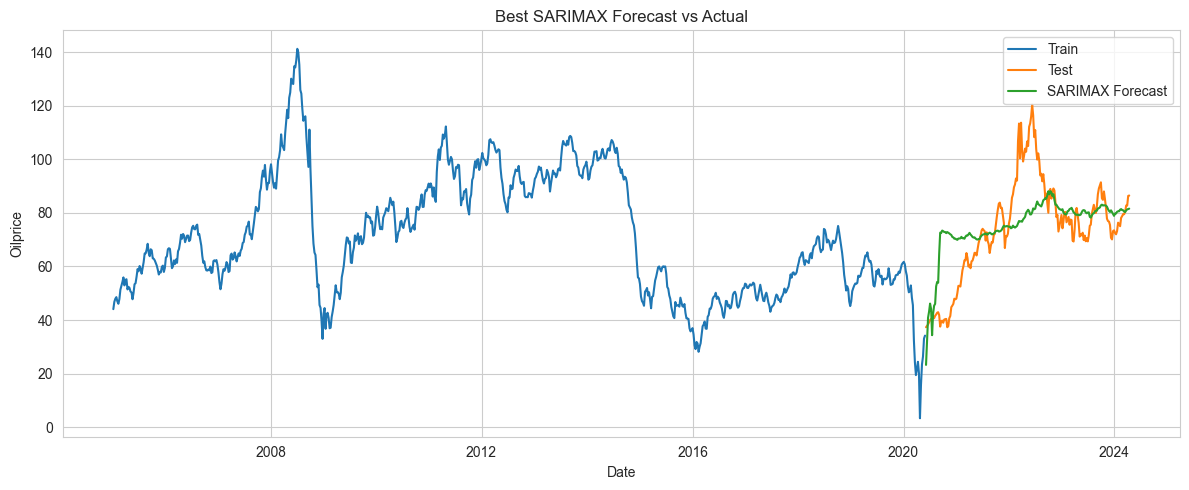

In [19]:

best_sarimax_order = sarimax_results_df.loc[0, 'order']
best_sarimax_seasonal = sarimax_results_df.loc[0, 'seasonal_order']

print('Best SARIMAX order:', best_sarimax_order)
print('Best SARIMAX seasonal order:', best_sarimax_seasonal)

best_sarimax_model = SARIMAX(
    train_endog,
    exog=train_exog,
    order=best_sarimax_order,
    seasonal_order=best_sarimax_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

best_sarimax_forecast = best_sarimax_model.forecast(steps=len(test_endog), exog=test_exog)
best_sarimax_metrics = regression_metrics(test_endog, best_sarimax_forecast)
print(best_sarimax_metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_endog.index, train_endog, label='Train')
plt.plot(test_endog.index, test_endog, label='Test')
plt.plot(test_endog.index, best_sarimax_forecast, label='SARIMAX Forecast')
plt.title('Best SARIMAX Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Oilprice')
plt.legend()
plt.tight_layout()
plt.show()


## 12. ANN modeling framework

The ANN models are implemented using `MLPRegressor` inside a pipeline with `MinMaxScaler`.

### Why this setup?
- scaling is important for neural networks
- `MLPRegressor` is easy to tune with `RandomizedSearchCV`
- `TimeSeriesSplit` is used instead of random cross-validation

### Two ANN experiments
1. **ANN + oil only**
2. **ANN + oil + US Index**


### 12.1 ANN + oil only

In [20]:

# Create supervised data using only oil lags
lags_oil_only = 4
supervised_oil_only, X_oil_only, y_oil_only = create_supervised_features(
    weekly_data_clean,
    target_col='Oilprice',
    exog_cols=[],
    lags=lags_oil_only
)

X_train_oil, X_test_oil, y_train_oil, y_test_oil = train_test_split_time_series(X_oil_only, y_oil_only, train_ratio=0.8)

print('Oil-only supervised shape:', supervised_oil_only.shape)
print('X_train:', X_train_oil.shape, 'X_test:', X_test_oil.shape)


Oil-only supervised shape: (1002, 5)
X_train: (801, 4) X_test: (201, 4)


In [22]:

ann_pipeline_oil = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPRegressor(max_iter=2000, random_state=42, early_stopping=True))
])

param_dist_oil = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (64,), (32, 16), (64, 32), (64, 32, 16)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.0005, 0.001, 0.01],
    'mlp__batch_size': [8, 16, 32]
}

ts_cv = TimeSeriesSplit(n_splits=5)

random_search_oil = RandomizedSearchCV(
    estimator=ann_pipeline_oil,
    param_distributions=param_dist_oil,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=ts_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_oil.fit(X_train_oil, y_train_oil)

print('Best ANN (oil only) params:')
print(random_search_oil.best_params_)
print('Best CV score:', -random_search_oil.best_score_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best ANN (oil only) params:
{'mlp__solver': 'adam', 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (64, 32, 16), 'mlp__batch_size': 8, 'mlp__alpha': 0.01, 'mlp__activation': 'relu'}
Best CV score: 4.4603185118438855


{'RMSE': 3.2972573438861468, 'MAE': 2.381885657440378, 'MAPE': np.float64(3.083211720463875), 'R2': 0.9691510041682323}


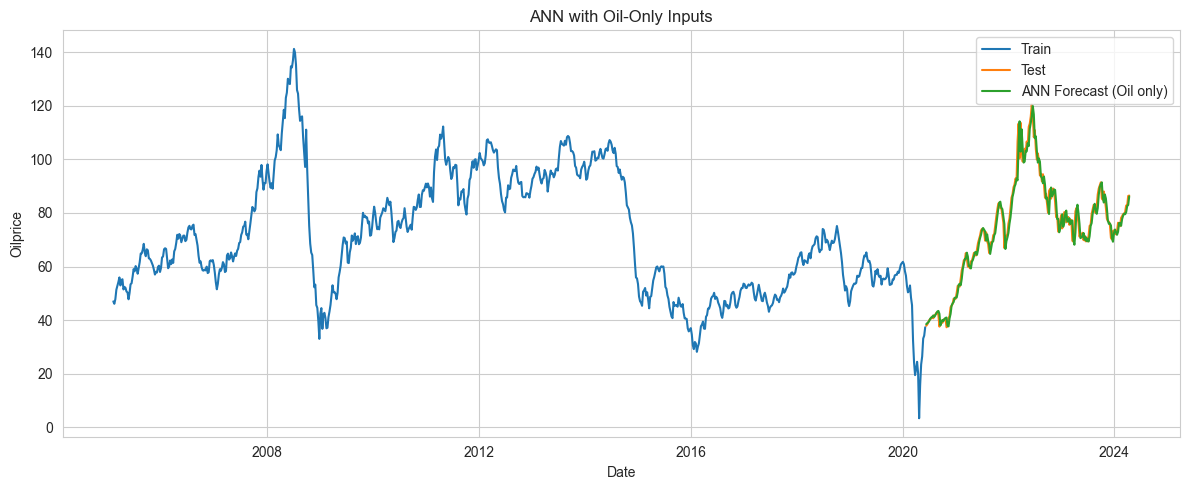

In [23]:
best_ann_oil = random_search_oil.best_estimator_
pred_ann_oil = best_ann_oil.predict(X_test_oil)

best_ann_oil_metrics = regression_metrics(y_test_oil, pred_ann_oil)
print(best_ann_oil_metrics)

plt.figure(figsize=(12, 5))
plt.plot(y_train_oil.index, y_train_oil, label='Train')
plt.plot(y_test_oil.index, y_test_oil, label='Test')
plt.plot(y_test_oil.index, pred_ann_oil, label='ANN Forecast (Oil only)')
plt.title('ANN with Oil-Only Inputs')
plt.xlabel('Date')
plt.ylabel('Oilprice')
plt.legend()
plt.tight_layout()
plt.show()


### 12.2 ANN + oil + US Index

In [24]:

# Create supervised data using oil lags and US Index lags
lags_oil_us = 4
supervised_oil_us, X_oil_us, y_oil_us = create_supervised_features(
    weekly_data_clean,
    target_col='Oilprice',
    exog_cols=['us-index'],
    lags=lags_oil_us
)

X_train_oil_us, X_test_oil_us, y_train_oil_us, y_test_oil_us = train_test_split_time_series(X_oil_us, y_oil_us, train_ratio=0.8)

print('Oil + US Index supervised shape:', supervised_oil_us.shape)
print('X_train:', X_train_oil_us.shape, 'X_test:', X_test_oil_us.shape)


Oil + US Index supervised shape: (1002, 9)
X_train: (801, 8) X_test: (201, 8)


In [25]:

ann_pipeline_oil_us = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPRegressor(max_iter=2000, random_state=42, early_stopping=True))
])

param_dist_oil_us = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (64,), (32, 16), (64, 32), (64, 32, 16)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.0005, 0.001, 0.01],
    'mlp__batch_size': [8, 16, 32]
}

random_search_oil_us = RandomizedSearchCV(
    estimator=ann_pipeline_oil_us,
    param_distributions=param_dist_oil_us,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=ts_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_oil_us.fit(X_train_oil_us, y_train_oil_us)

print('Best ANN (oil + US Index) params:')
print(random_search_oil_us.best_params_)
print('Best CV score:', -random_search_oil_us.best_score_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best ANN (oil + US Index) params:
{'mlp__solver': 'adam', 'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (32, 16), 'mlp__batch_size': 16, 'mlp__alpha': 0.01, 'mlp__activation': 'relu'}
Best CV score: 3.817203792401157


{'RMSE': 3.411474077981775, 'MAE': 2.527193375717607, 'MAPE': np.float64(3.271665111810116), 'R2': 0.9669767741531446}


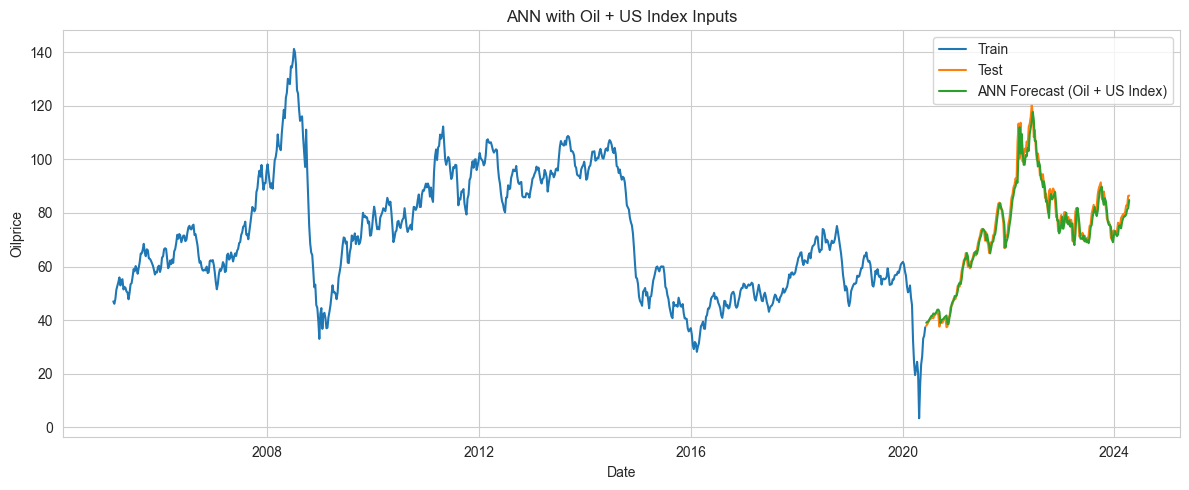

In [26]:

best_ann_oil_us = random_search_oil_us.best_estimator_
pred_ann_oil_us = best_ann_oil_us.predict(X_test_oil_us)

best_ann_oil_us_metrics = regression_metrics(y_test_oil_us, pred_ann_oil_us)
print(best_ann_oil_us_metrics)

plt.figure(figsize=(12, 5))
plt.plot(y_train_oil_us.index, y_train_oil_us, label='Train')
plt.plot(y_test_oil_us.index, y_test_oil_us, label='Test')
plt.plot(y_test_oil_us.index, pred_ann_oil_us, label='ANN Forecast (Oil + US Index)')
plt.title('ANN with Oil + US Index Inputs')
plt.xlabel('Date')
plt.ylabel('Oilprice')
plt.legend()
plt.tight_layout()
plt.show()



## 13. Final model comparison

This section consolidates the performance of all four models into one comparison table.


In [27]:

comparison_df = pd.DataFrame([
    {'Model': 'ARIMA baseline', **best_arima_metrics},
    {'Model': 'SARIMAX + oil + us-index', **best_sarimax_metrics},
    {'Model': 'ANN + oil', **best_ann_oil_metrics},
    {'Model': 'ANN + oil + us-index', **best_ann_oil_us_metrics},
]).sort_values('RMSE').reset_index(drop=True)

comparison_df


,Model,RMSE,MAE,MAPE,R2
0,ANN + oil,3.297257,2.381886,3.083212,0.969151
1,ANN + oil + us-index,3.411474,2.527193,3.271665,0.966977
2,SARIMAX + oil + us-index,14.524281,10.363937,16.223698,0.409768
3,ARIMA baseline,18.372167,14.002738,17.041775,0.055604


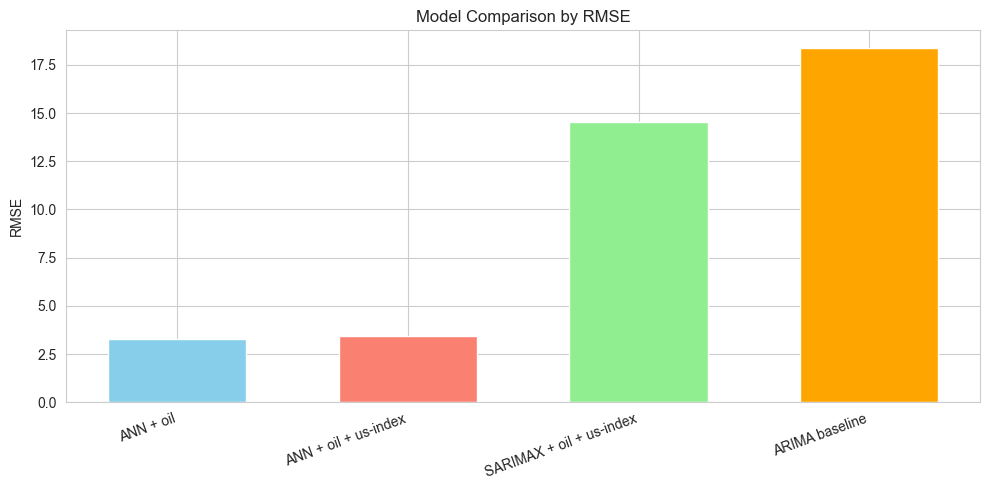

In [ ]:

plt.figure(figsize=(10, 5))
plt.bar(comparison_df['Model'], comparison_df['RMSE'], width=0.4, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Model Comparison by RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
